# Notebook 05 — Optimización de Hiperparámetros con Optuna

Proyecto: Clasificación de ensayos EEG [match vs mismatch].  
Track elegido: Track A - ML Clásico  
Autores: Jose Pablo Agüero Mora, Roilin Navarro Vargas

# Objetivo

En este notebook se ajustan hiperparámetros de dos modelos candidatos usando Optuna, manteniendo el mismo protocolo experimental de los notebooks anteriores (validación cruzada por sujeto con GroupKFold). El objetivo es comparar las familias con un ajuste razonable y escoger un modelo final para evaluar en sujetos no vistos.

Se ajustan LogisticRegression y LightGBM porque en el Notebook 04 ambos quedaron con resultados muy cercanos. El ajuste se realiza únicamente con el conjunto de CV (los sujetos de holdout se mantienen aparte y no se usan en el proceso de tuning).

Optuna se usa porque permite explorar el espacio de búsqueda de forma más eficiente que un grid fijo (con muestreo TPE), además de poder detener trials poco prometedores con pruning y guardar el progreso del estudio en un storage local (SQLite).

## 1. Configuración

In [1]:
PROJECT_ROOT_DRIVE = '/content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400'

# Número de trials por modelo
N_TRIALS = 100

# Forzar re-tuning aunque el estudio ya exista
FORCE_RERUN = False

print(f'PROJECT_ROOT_DRIVE: {PROJECT_ROOT_DRIVE}')
print(f'N_TRIALS:           {N_TRIALS}')
print(f'FORCE_RERUN:        {FORCE_RERUN}')

PROJECT_ROOT_DRIVE: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400
N_TRIALS:           100
FORCE_RERUN:        False


## 2. Instalación más reinicio: recordar saltar `os.kill` en el segundo pase

In [2]:
%%capture
!pip install -q --upgrade --no-cache-dir "shap>=0.46.0"
!pip install -q mne==1.12.1
!pip install -q scikit-learn xgboost lightgbm optuna
!pip install -q pyxdf openpyxl pyyaml tqdm jedi

In [ ]:
import os
os.kill(os.getpid(), 9)

## 3. Imports

In [3]:
import os
import sys
import json
import yaml
import random
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix
)
from lightgbm import LGBMClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f'Python:       {sys.version.split()[0]}')
print(f'NumPy:        {np.__version__}')
print(f'scikit-learn: {__import__("sklearn").__version__}')
print(f'LightGBM:     {__import__("lightgbm").__version__}')
print(f'Optuna:       {optuna.__version__}')

Python:       3.12.13
NumPy:        2.0.2
scikit-learn: 1.6.1
LightGBM:     4.6.0
Optuna:       4.8.0


## 4. Drive y configuración

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

CONFIG_PATH = Path(PROJECT_ROOT_DRIVE) / 'configs' / 'main_config.yaml'
with open(CONFIG_PATH, 'r') as f:
    CFG = yaml.safe_load(f)

SEED = CFG['seed']
random.seed(SEED)
np.random.seed(SEED)

REPORTS_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['reports_dir']
FIGURES_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['figures_dir']
FEATURES_DIR = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['features_dir']
MODELS_DIR   = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['models_dir']
LOGS_DIR     = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['logs_dir']
LOGS_DIR.mkdir(parents=True, exist_ok=True)

print(f' Config cargada (seed = {SEED})')

Mounted at /content/drive
 Config cargada (seed = 42)


## 5. Cargar matriz de features y holdout split

In [5]:
df = pd.read_csv(FEATURES_DIR / '02_features_matrix.csv')
feature_cols = [c for c in df.columns if c not in ['subject_id', 'epoch_idx', 'condition', 'label']]

with open(MODELS_DIR / 'holdout_split.json', 'r') as f:
    split_info = json.load(f)

df_cv = df[df['subject_id'].isin(split_info['cv_subjects'])].reset_index(drop=True)
X_cv = df_cv[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
y_cv = df_cv['label'].values
groups_cv = df_cv['subject_id'].values

assert len(set(df_cv['subject_id']) & set(split_info['holdout_subjects'])) == 0, '¡LEAKAGE!'
print(f' Dataset CV: {X_cv.shape}, {len(np.unique(groups_cv))} sujetos')
print(f'  match={sum(y_cv==0)}  mismatch={sum(y_cv==1)}')

 Dataset CV: (1238, 72), 24 sujetos
  match=709  mismatch=529


## 6. Definir funciones auxiliares

In [6]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_iter=1000, ci=0.95, seed=SEED):
    n = len(y_true)
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        try:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception:
            continue
    return float(np.mean(scores)), float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))


def cv_f1_macro(pipeline, X, y, groups, n_splits=5):
    """Macro F1 promedio sobre GroupKFold folds."""
    gkf = GroupKFold(n_splits=n_splits)
    scores = cross_val_score(pipeline, X, y, groups=groups, cv=gkf, scoring='f1_macro', n_jobs=1)
    return float(np.mean(scores))

print(' Funciones definidas')

 Funciones definidas


## 7. Optuna: Estudio para LogisticRegression

In [7]:
def objective_logreg(trial):
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    C = trial.suggest_float('C', 1e-3, 100.0, log=True)

    if penalty == 'l1':
        solver = 'saga'
        l1_ratio = None
    elif penalty == 'l2':
        solver = 'lbfgs'
        l1_ratio = None
    else:  # elasticnet
        solver = 'saga'
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)

    clf_kwargs = dict(
        penalty=penalty, C=C, solver=solver,
        class_weight='balanced', max_iter=5000,
        random_state=SEED,
    )
    if l1_ratio is not None:
        clf_kwargs['l1_ratio'] = l1_ratio

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(**clf_kwargs))
    ])
    return cv_f1_macro(pipeline, X_cv, y_cv, groups_cv, n_splits=CFG['splits']['cv_n_splits'])


# Storage persistente en Drive: resumible
storage_logreg = f'sqlite:///{LOGS_DIR}/optuna_logreg.db'
study_logreg = optuna.create_study(
    study_name='logreg_tuning',
    storage=storage_logreg,
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(),
    load_if_exists=True
)

n_done = len(study_logreg.trials)
print(f'Trials ya hechos: {n_done}')
n_to_do = max(0, N_TRIALS - n_done)
print(f'Trials a ejecutar: {n_to_do}')

if n_to_do > 0:
    t0 = time.time()
    study_logreg.optimize(objective_logreg, n_trials=n_to_do, show_progress_bar=True)
    print(f'\nTiempo total: {(time.time()-t0)/60:.1f} min')

print(f'\nMejor Macro F1 (CV): {study_logreg.best_value:.4f}')
print(f'Mejores hiperparámetros: {study_logreg.best_params}')

Trials ya hechos: 100
Trials a ejecutar: 0

Mejor Macro F1 (CV): 0.5304
Mejores hiperparámetros: {'penalty': 'l2', 'C': 48.471680171699674}


In [8]:
# Guardar historia de trials
df_trials_logreg = study_logreg.trials_dataframe()
df_trials_logreg.to_csv(REPORTS_DIR / '05_optuna_history_logreg.csv', index=False)
print(f' Historia guardada: reports/05_optuna_history_logreg.csv')
print(f'  Total trials: {len(df_trials_logreg)}')
print(f'  Trials completados: {(df_trials_logreg["state"] == "COMPLETE").sum()}')
print(f'  Trials pruned:     {(df_trials_logreg["state"] == "PRUNED").sum()}')

 Historia guardada: reports/05_optuna_history_logreg.csv
  Total trials: 100
  Trials completados: 100
  Trials pruned:     0


## 8. Optuna: Estudio para LightGBM

Espacio de búsqueda con 9 hiperparámetro:
- n_estimators: [50, 500]
- learning_rate: log-uniform [0.01, 0.3]
- max_depth: [3, 12]
- num_leaves: [10, 80]
- min_child_samples: [5, 100]: esto es importante para evitar overfitting con N pequeño
- reg_alpha, reg_lambda: regularización L1/L2
- subsample, colsample_bytree: regularización por filas y columnas

In [9]:
def objective_lightgbm(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'num_leaves':        trial.suggest_int('num_leaves', 10, 80),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'class_weight':      'balanced',
        'n_jobs':            -1,
        'random_state':      SEED,
        'verbosity':         -1,
    }
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LGBMClassifier(**params))
    ])
    return cv_f1_macro(pipeline, X_cv, y_cv, groups_cv, n_splits=CFG['splits']['cv_n_splits'])


storage_lgbm = f'sqlite:///{LOGS_DIR}/optuna_lightgbm.db'
study_lgbm = optuna.create_study(
    study_name='lightgbm_tuning',
    storage=storage_lgbm,
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(),
    load_if_exists=True
)

n_done = len(study_lgbm.trials)
print(f'Trials ya hechos: {n_done}')
n_to_do = max(0, N_TRIALS - n_done)
print(f'Trials a ejecutar: {n_to_do}')

if n_to_do > 0:
    t0 = time.time()
    study_lgbm.optimize(objective_lightgbm, n_trials=n_to_do, show_progress_bar=True)
    print(f'\nTiempo total: {(time.time()-t0)/60:.1f} min')

print(f'\nMejor Macro F1 (CV): {study_lgbm.best_value:.4f}')
print(f'Mejores hiperparámetros: {study_lgbm.best_params}')

df_trials_lgbm = study_lgbm.trials_dataframe()
df_trials_lgbm.to_csv(REPORTS_DIR / '05_optuna_history_lightgbm.csv', index=False)
print(f' Historia guardada: reports/05_optuna_history_lightgbm.csv')

Trials ya hechos: 100
Trials a ejecutar: 0

Mejor Macro F1 (CV): 0.5530
Mejores hiperparámetros: {'n_estimators': 74, 'learning_rate': 0.012504220625190469, 'max_depth': 9, 'num_leaves': 78, 'min_child_samples': 89, 'reg_alpha': 0.0032369337277773137, 'reg_lambda': 0.02208519739996559, 'subsample': 0.8204468563361671, 'colsample_bytree': 0.7196443590899224}
 Historia guardada: reports/05_optuna_history_lightgbm.csv


## 9. Evaluación de los dos modelos ya tuneados

In [10]:
def build_logreg_from_params(params):
    kwargs = dict(
        penalty=params['penalty'], C=params['C'],
        class_weight='balanced', max_iter=5000, random_state=SEED
    )
    if params['penalty'] == 'l1':
        kwargs['solver'] = 'saga'
    elif params['penalty'] == 'l2':
        kwargs['solver'] = 'lbfgs'
    else:
        kwargs['solver'] = 'saga'
        kwargs['l1_ratio'] = params['l1_ratio']
    return Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(**kwargs))])


def build_lgbm_from_params(params):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LGBMClassifier(**params, class_weight='balanced', n_jobs=-1,
                               random_state=SEED, verbosity=-1))
    ])


def evaluate_with_ci(pipeline, X, y, groups, name='model', n_boot=1000):
    """CV con todas las métricas + bootstrap CI."""
    gkf = GroupKFold(n_splits=CFG['splits']['cv_n_splits'])
    y_pred = cross_val_predict(pipeline, X, y, groups=groups, cv=gkf, n_jobs=1)
    try:
        y_proba = cross_val_predict(pipeline, X, y, groups=groups, cv=gkf,
                                    method='predict_proba', n_jobs=1)[:, 1]
    except Exception:
        y_proba = None

    acc_m, acc_lo, acc_hi = bootstrap_ci(y, y_pred, lambda a, b: accuracy_score(a, b), n_iter=n_boot)
    f1m_m, f1m_lo, f1m_hi = bootstrap_ci(y, y_pred, lambda a, b: f1_score(a, b, average='macro'), n_iter=n_boot)
    pre_m, _, _ = bootstrap_ci(y, y_pred, lambda a, b: precision_score(a, b, average='macro', zero_division=0), n_iter=n_boot)
    rec_m, _, _ = bootstrap_ci(y, y_pred, lambda a, b: recall_score(a, b, average='macro', zero_division=0), n_iter=n_boot)
    if y_proba is not None:
        auc_m, auc_lo, auc_hi = bootstrap_ci(y, y_proba, lambda a, b: roc_auc_score(a, b), n_iter=n_boot)
    else:
        auc_m = auc_lo = auc_hi = np.nan

    return {
        'name': name,
        'accuracy': acc_m, 'accuracy_lo': acc_lo, 'accuracy_hi': acc_hi,
        'f1_macro': f1m_m, 'f1_macro_lo': f1m_lo, 'f1_macro_hi': f1m_hi,
        'precision_macro': pre_m, 'recall_macro': rec_m,
        'roc_auc': auc_m, 'roc_auc_lo': auc_lo, 'roc_auc_hi': auc_hi,
        'y_pred': y_pred, 'y_proba': y_proba, 'y_true': y,
    }


# Construir los dos modelos tuneados y evaluarlos
logreg_tuned = build_logreg_from_params(study_logreg.best_params)
lgbm_tuned   = build_lgbm_from_params(study_lgbm.best_params)

print('Evaluando LogReg tuneado con CV más bootstrap CI:')
r_logreg = evaluate_with_ci(logreg_tuned, X_cv, y_cv, groups_cv, name='LogisticRegression (tuned)',
                             n_boot=CFG['metrics']['bootstrap_n_iterations'])
print(f'  Macro F1: {r_logreg["f1_macro"]:.3f}  [{r_logreg["f1_macro_lo"]:.3f}, {r_logreg["f1_macro_hi"]:.3f}]')

print('\nEvaluando LightGBM tuneado con CV más bootstrap CI')
r_lgbm = evaluate_with_ci(lgbm_tuned, X_cv, y_cv, groups_cv, name='LightGBM (tuned)',
                          n_boot=CFG['metrics']['bootstrap_n_iterations'])
print(f'  Macro F1: {r_lgbm["f1_macro"]:.3f}  [{r_lgbm["f1_macro_lo"]:.3f}, {r_lgbm["f1_macro_hi"]:.3f}]')

Evaluando LogReg tuneado con CV más bootstrap CI:
  Macro F1: 0.535  [0.508, 0.562]

Evaluando LightGBM tuneado con CV más bootstrap CI


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  Macro F1: 0.558  [0.531, 0.587]


## 11. Comparación final

In [11]:
# Cargar baselines y modelos del Notebook 03/04 para comparar
df_baselines = pd.read_csv(REPORTS_DIR / '03_baselines_results.csv')
df_models04 = pd.read_csv(REPORTS_DIR / '04_models_cv_comparison.csv')

rows = []
for _, r in df_baselines.iterrows():
    rows.append({'tipo':'baseline','modelo':r['modelo'],
                 'f1_macro':r['f1_macro'],'f1_macro_lo':r['f1_macro_lo'],'f1_macro_hi':r['f1_macro_hi']})
for _, r in df_models04.iterrows():
    rows.append({'tipo':'sin tuning','modelo':r['modelo'],
                 'f1_macro':r['f1_macro'],'f1_macro_lo':r['f1_macro_lo'],'f1_macro_hi':r['f1_macro_hi']})
rows.append({'tipo':'TUNEADO','modelo':r_logreg['name'],
             'f1_macro':r_logreg['f1_macro'],'f1_macro_lo':r_logreg['f1_macro_lo'],'f1_macro_hi':r_logreg['f1_macro_hi']})
rows.append({'tipo':'TUNEADO','modelo':r_lgbm['name'],
             'f1_macro':r_lgbm['f1_macro'],'f1_macro_lo':r_lgbm['f1_macro_lo'],'f1_macro_hi':r_lgbm['f1_macro_hi']})

df_final = pd.DataFrame(rows).sort_values('f1_macro', ascending=False).reset_index(drop=True)
df_final.to_csv(REPORTS_DIR / '05_final_comparison.csv', index=False)

print('=== COMPARACIÓN GENERAL (CV, ordenado por Macro F1) ===\n')
display_df = df_final.copy()
display_df['f1_macro_with_ci'] = display_df.apply(
    lambda r: f'{r["f1_macro"]:.3f} [{r["f1_macro_lo"]:.3f}, {r["f1_macro_hi"]:.3f}]', axis=1)
print(display_df[['tipo','modelo','f1_macro_with_ci']].to_string(index=False))
print(f'\n Guardado: reports/05_final_comparison.csv')

=== COMPARACIÓN GENERAL (CV, ordenado por Macro F1) ===

      tipo                                       modelo     f1_macro_with_ci
   TUNEADO                             LightGBM (tuned) 0.558 [0.531, 0.587]
   TUNEADO                   LogisticRegression (tuned) 0.535 [0.508, 0.562]
sin tuning                        LogisticRegression_L2 0.520 [0.494, 0.549]
sin tuning                                     LightGBM 0.518 [0.491, 0.545]
  baseline Heurístico ERP extendido (De las 4 features) 0.516 [0.487, 0.542]
sin tuning                                      SVM_RBF 0.510 [0.484, 0.538]
  baseline          Heurístico ERP [LogReg, 2 features] 0.501 [0.473, 0.529]
  baseline                           Dummy (stratified) 0.498 [0.472, 0.527]
sin tuning                                      XGBoost 0.495 [0.469, 0.522]
sin tuning                                 RandomForest 0.446 [0.421, 0.473]
  baseline                        Dummy (most_frequent) 0.364 [0.352, 0.375]

 Guardado: reports

## 12. Visualizaciones de Optuna

 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/05_optuna_summary.png


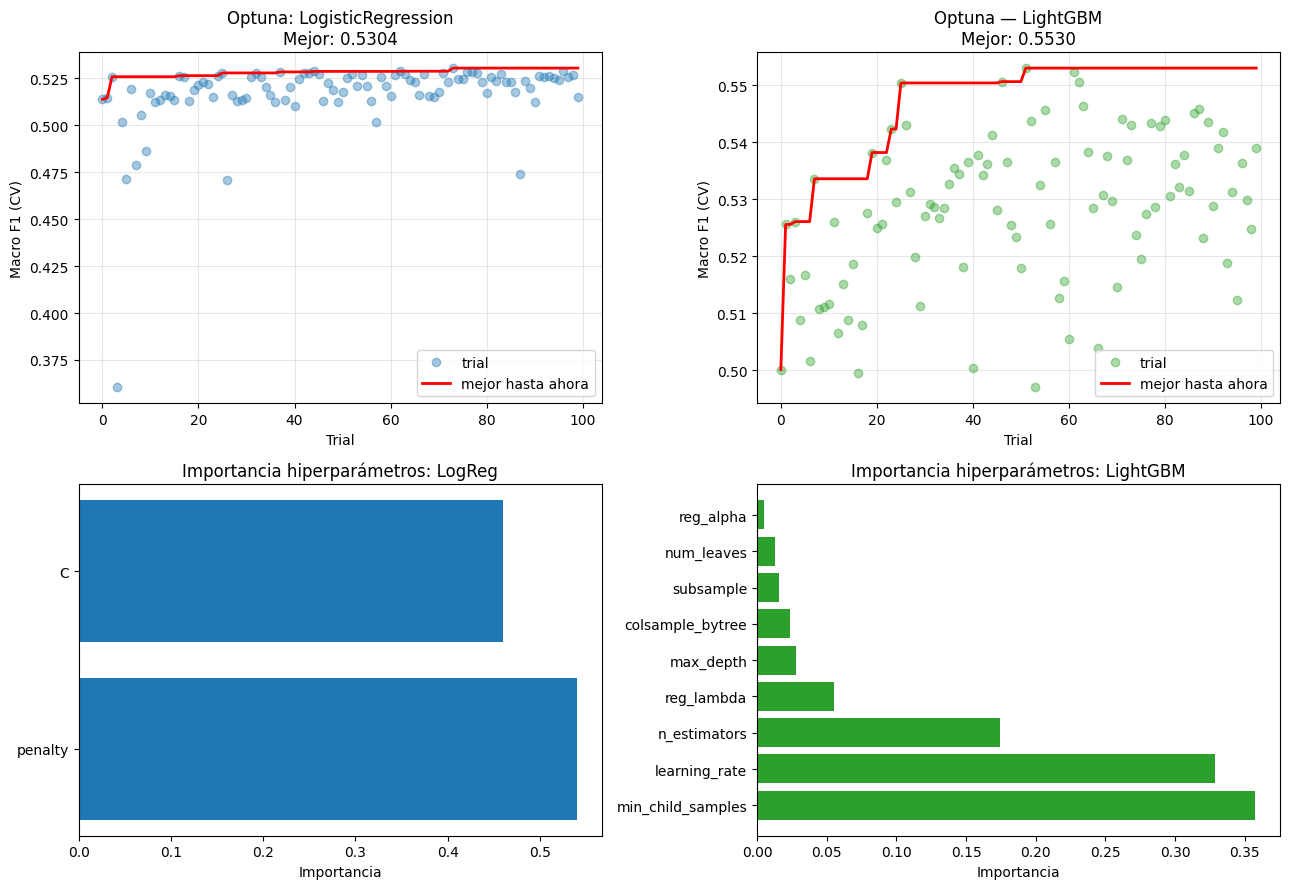

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Historia de optimización LogReg
ax = axes[0, 0]
values = [t.value for t in study_logreg.trials if t.value is not None]
best_so_far = np.maximum.accumulate(values)
ax.plot(range(len(values)), values, 'o', alpha=0.4, color='tab:blue', label='trial')
ax.plot(range(len(best_so_far)), best_so_far, '-', color='red', linewidth=2, label='mejor hasta ahora')
ax.set_xlabel('Trial')
ax.set_ylabel('Macro F1 (CV)')
ax.set_title(f'Optuna: LogisticRegression\nMejor: {study_logreg.best_value:.4f}')
ax.legend()
ax.grid(alpha=0.3)

# Historia LightGBM
ax = axes[0, 1]
values = [t.value for t in study_lgbm.trials if t.value is not None]
best_so_far = np.maximum.accumulate(values)
ax.plot(range(len(values)), values, 'o', alpha=0.4, color='tab:green', label='trial')
ax.plot(range(len(best_so_far)), best_so_far, '-', color='red', linewidth=2, label='mejor hasta ahora')
ax.set_xlabel('Trial')
ax.set_ylabel('Macro F1 (CV)')
ax.set_title(f'Optuna — LightGBM\nMejor: {study_lgbm.best_value:.4f}')
ax.legend()
ax.grid(alpha=0.3)

# Importancia de hiperparámetros LogReg
ax = axes[1, 0]
try:
    importances = optuna.importance.get_param_importances(study_logreg)
    if importances:
        params, vals = zip(*importances.items())
        ax.barh(params, vals, color='tab:blue')
    ax.set_xlabel('Importancia')
    ax.set_title('Importancia hiperparámetros: LogReg')
except Exception as e:
    ax.text(0.5, 0.5, f'No disponible: {e}', ha='center')

# Importancia LightGBM
ax = axes[1, 1]
try:
    importances = optuna.importance.get_param_importances(study_lgbm)
    if importances:
        params, vals = zip(*importances.items())
        ax.barh(params, vals, color='tab:green')
    ax.set_xlabel('Importancia')
    ax.set_title('Importancia hiperparámetros: LightGBM')
except Exception as e:
    ax.text(0.5, 0.5, f'No disponible: {e}', ha='center')

plt.tight_layout()
fig_path = FIGURES_DIR / '05_optuna_summary.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

## 13. Selección

Aquí se comparan los dos modelos tuneados usando la métrica objetivo (macro F1 en validación cruzada). El modelo seleccionado se reentrena con todos los sujetos del conjunto de CV y se guarda en disco junto con sus hiperparámetros, para poder reutilizarlo en la evaluación final y en la integración posterior.

In [13]:
# Elegir el ganador por Macro F1 (single-trial CV)
if r_logreg['f1_macro'] >= r_lgbm['f1_macro']:
    winner_name = 'LogisticRegression_tuned'
    winner_pipeline = logreg_tuned
    winner_result = r_logreg
    winner_params = study_logreg.best_params
else:
    winner_name = 'LightGBM_tuned'
    winner_pipeline = lgbm_tuned
    winner_result = r_lgbm
    winner_params = study_lgbm.best_params

print(f'=== MODELO FINAL ===')
print(f'Ganador:        {winner_name}')
print(f'Macro F1 (CV): {winner_result["f1_macro"]:.3f}  [{winner_result["f1_macro_lo"]:.3f}, {winner_result["f1_macro_hi"]:.3f}]')
print(f'Accuracy (CV): {winner_result["accuracy"]:.3f}  [{winner_result["accuracy_lo"]:.3f}, {winner_result["accuracy_hi"]:.3f}]')
print(f'ROC-AUC  (CV): {winner_result["roc_auc"]:.3f}  [{winner_result["roc_auc_lo"]:.3f}, {winner_result["roc_auc_hi"]:.3f}]')

print(f'\nMejores hiperparámetros:')
for k, v in winner_params.items():
    print(f'  {k}: {v}')

# Re-entrenar sobre TODO el conjunto de CV (sin folds)
print(f'\nEntrenando modelo final sobre los 24 sujetos del CV...')
winner_pipeline.fit(X_cv, y_cv)

# Guardar
with open(MODELS_DIR / 'best_model.pkl', 'wb') as f:
    pickle.dump(winner_pipeline, f)

with open(MODELS_DIR / 'best_hyperparameters.json', 'w') as f:
    json.dump({
        'winner_name': winner_name,
        'hyperparameters': winner_params,
        'cv_f1_macro': winner_result['f1_macro'],
        'cv_f1_macro_ci': [winner_result['f1_macro_lo'], winner_result['f1_macro_hi']],
        'cv_accuracy': winner_result['accuracy'],
        'cv_roc_auc': winner_result['roc_auc'],
    }, f, indent=2, default=str)

print(f'\n Modelo guardado: {MODELS_DIR}/best_model.pkl')
print(f' Hiperparámetros guardados: {MODELS_DIR}/best_hyperparameters.json')

=== MODELO FINAL ===
Ganador:        LightGBM_tuned
Macro F1 (CV): 0.558  [0.531, 0.587]
Accuracy (CV): 0.565  [0.537, 0.593]
ROC-AUC  (CV): 0.547  [0.516, 0.578]

Mejores hiperparámetros:
  n_estimators: 74
  learning_rate: 0.012504220625190469
  max_depth: 9
  num_leaves: 78
  min_child_samples: 89
  reg_alpha: 0.0032369337277773137
  reg_lambda: 0.02208519739996559
  subsample: 0.8204468563361671
  colsample_bytree: 0.7196443590899224

Entrenando modelo final sobre los 24 sujetos del CV...

 Modelo guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/models/best_model.pkl
 Hiperparámetros guardados: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/models/best_hyperparameters.json
